In [15]:
#without GP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import batman
from transitleastsquares import transitleastsquares
import seaborn as sns
import os
from functools import lru_cache
from itertools import product
from scipy.signal import savgol_filter

def get_lightcurve(tic, st_tmag, st_rad, st_mass, st_teff):
    lc_collection = lk.search_lightcurve(tic, mission="TESS", author="TESS-SPOC", cadence="long").download_all(quality_bitmask="hard")
    if lc_collection is None or len(lc_collection) == 0:
        return None

    sector_length = len(lc_collection)


    return pd.DataFrame({'tic': [tic], 'sector_length': [sector_length], 'st_tmag': [st_tmag], 'st_rad': [st_rad], 'st_mass': [st_mass], 'st_teff': [st_teff]})

star_params = pd.read_csv("stellar_params_CTL.csv")

CTL_sectors = pd.DataFrame()
for i, row in star_params.iterrows():
    tic = f"TIC {int(row['id'])}"
    st_tmag = row['st_tmag']
    st_rad = row['st_rad']
    st_mass = row['mst']
    st_teff = row['st_teff']
    df_results = get_lightcurve(tic, st_tmag, st_rad, st_mass, st_teff)
    try:
        print(f'{i} tic {tic}: sector length {df_results["sector_length"].values[0]}, tmag {st_tmag}, rad {st_rad}, mass {st_mass}, teff {st_teff}')
        df_results.to_csv("CTL_sector_results.csv", mode='a', header=not os.path.exists("CTL_sector_results.csv"), index=False)
    except Exception as e:
        print(f"Error processing {tic}: {e}")
    CTL_sectors = pd.concat([CTL_sectors, df_results], ignore_index=True)
    


0 tic TIC 158235404: sector length 2, tmag 11.285, rad 0.18000001, mass 0.47, teff 31000.0
1 tic TIC 13145616: sector length 1, tmag 11.287, rad 0.18000001, mass 0.47, teff 29840.0


2 tic TIC 290928016: sector length 2, tmag 11.7196, rad 0.259087, mass 0.23075999, teff 3214.0
3 tic TIC 119886634: sector length 1, tmag 12.7229, rad 0.233468, mass 0.20319299, teff 3351.0


4 tic TIC 137156909: sector length 4, tmag 12.7278, rad 0.258977, mass 0.230639, teff 3385.0
5 tic TIC 283410775: sector length 1, tmag 9.3268099, rad 0.312879, mass 0.29136401, teff 3240.0
Error processing TIC 415085843: 'NoneType' object is not subscriptable
Error processing TIC 277491425: 'NoneType' object is not subscriptable


/Users/danayaptangco/opt/anaconda3/envs/Mulders/lib/python3.9/site-packages/lightkurve/search.py:494: LightkurveWarning: Cannot download from an empty search result.
  warnings.warn(


8 tic TIC 336961885: sector length 2, tmag 11.4961, rad 0.28537899, mass 0.26002601, teff 3341.0
9 tic TIC 422079423: sector length 1, tmag 11.5666, rad 0.27715299, mass 0.250781, teff 3232.0


...

1177 tic TIC 149449530: sector length 24, tmag 9.368, rad 2.02704, mass 1.5700001, teff 7087.0


1178 tic TIC 244951421: sector length 3, tmag 9.9523497, rad 2.0090899, mass 1.313, teff 6460.0
1179 tic TIC 155175631: sector length 3, tmag 10.1371, rad 1.99349, mass 1.01, teff 5684.29


1180 tic TIC 407772261: sector length 3, tmag 10.1068, rad 1.88297, mass 1.66, teff 7326.0
1181 tic TIC 178284735: sector length 3, tmag 7.3335099, rad 2.7625, mass 1.25, teff 6328.98
1182 tic TIC 241204178: sector length 2, tmag 7.8441, rad 2.45784, mass 1.353, teff 6546.0
1183 tic TIC 97598151: sector length 1, tmag 8.3857002, rad 2.66291, mass 2.3069999, teff 9118.0
1184 tic TIC 59078701: sector length 2, tmag 9.2379999, rad 2.65028, mass 1.596, teff 7153.7402
1185 tic TIC 219176929: sector length 17, tmag 9.1117001, rad 2.6162901, mass 1.5599999, teff 7044.5
1186 tic TIC 325209942: sector length 3, tmag 9.3278999, rad 2.2876899, mass 1.88, teff 7865.0
1187 tic TIC 75334343: sector length 3, tmag 10.32, rad 2.72629, mass 2.25, teff 8922.0
1188 tic TIC 70123698: sector length 3, tmag 8.6325903, rad 3.16678, mass 1.051, teff 5831.0


No data found for target "TIC 18203507".
/Users/danayaptangco/opt/anaconda3/envs/Mulders/lib/python3.9/site-packages/lightkurve/search.py:494: LightkurveWarning: Cannot download from an empty search result.
  warnings.warn(


Error processing TIC 18203507: 'NoneType' object is not subscriptable
1190 tic TIC 317654207: sector length 3, tmag 8.4598904, rad 4.5157199, mass 1.518, teff 6944.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import os
def get_lightcurve(toi, tic, st_tmag, st_rad, st_mass, st_teff):
    lc_collection = lk.search_lightcurve(tic, mission="TESS", author="TESS-SPOC", cadence="long").download_all(quality_bitmask="hard")
    if lc_collection is None or len(lc_collection) == 0:
        return None

    sector_length = len(lc_collection)


    return pd.DataFrame({'toi': [toi], 'tic': [tic], 'sector_length': [sector_length], 'st_tmag': [st_tmag], 'st_rad': [st_rad], 'st_mass': [st_mass], 'st_teff': [st_teff]})

star_params = pd.read_csv("TOI_Mar2025_1pt5to4_R_detected_real_only.csv")
star_params=star_params.iloc[0:]

TOI_sectors = pd.DataFrame()    
for i, row in star_params.iterrows():
    toi = row['toi']
    tic = f"TIC {int(row['id'])}"
    st_tmag = row['st_tmag']
    st_rad = row['st_rad']
    st_mass = row['mst']
    st_teff = row['st_teff']
    # Check if TOI already processed
    if os.path.exists("TOI_sector_results.csv"):
        existing = pd.read_csv("TOI_sector_results.csv")
        if toi in existing['toi'].values:
            continue
    try:
        df_results = get_lightcurve(toi, tic, st_tmag, st_rad, st_mass, st_teff)
        if df_results is not None:
            print(f'{i} {tic}: sector length {df_results["sector_length"].values[0]}, tmag {st_tmag}, rad {st_rad}, mass {st_mass}, teff {st_teff}')
            df_results.to_csv("TOI_sector_results.csv", mode='a', header=not os.path.exists("TOI_sector_results.csv"), index=False)
            TOI_sectors = pd.concat([TOI_sectors, df_results], ignore_index=True)
        else:
            print(f"{i} tic {tic}: No lightcurve found.")
    except Exception as e:
        print(f"Error processing {tic}: {e}")
    

3 TIC 87216634: sector length 1, tmag 6.5715, rad 0.88, mass 0.87, teff 5132.0


8 TIC 55450156: sector length 24, tmag 12.1851, rad 0.74, mass 0.88, teff 5203.0
9 TIC 77490011: sector length 1, tmag 14.1398, rad 0.232947, mass 0.20264401, teff 3244.0
20 TIC 52307802: sector length 5, tmag 12.747, rad 0.308247, mass 0.286048, teff 3246.0


32 TIC 30853470: sector length 24, tmag 11.3042, rad 0.693074, mass 0.74000001, teff 4662.0
61 TIC 59128183: sector length 4, tmag 12.4223, rad 0.502498, mass 0.50051898, teff 3609.0


62 TIC 91251292: sector length 3, tmag 10.671, rad 1.02672, mass 1.17, teff 6153.0
111 TIC 31142436: sector length 3, tmag 11.7732, rad 0.81, mass 0.91000003, teff 5294.0
118 TIC 35009898: sector length 4, tmag 12.2255, rad 0.427953, mass 0.42264301, teff 3433.0
140 TIC 33692729: sector length 2, tmag 8.7615, rad 1.00528, mass 0.91000003, teff 6114.0
155 TIC 27649847: sector length 5, tmag 12.4029, rad 0.420028, mass 0.41389501, teff 3439.0
227 TIC 60377863: sector length 4, tmag 9.4051, rad 1.15, mass 1.09, teff 5967.0
236 TIC 9907513: sector length 2, tmag 11.9639, rad 0.78, mass 0.66000003, teff 4216.7
284 TIC 29960110: sector length 2, tmag 10.9473, rad 0.482388, mass 0.480382, teff 3948.0
317 TIC 31374837: sector length 3, tmag 8.1705, rad 0.726632, mass 0.80000001, teff 4891.0


343 TIC 22233480: sector length 3, tmag 11.2695, rad 0.375859, mass 0.363996, teff 3353.0
384 TIC 29106627: sector length 2, tmag 11.1878, rad 0.767312, mass 0.82800001, teff 4998.0
392 TIC 5882269: sector length 3, tmag 12.0394, rad 0.65, mass 0.63700002, teff 4072.0
394 TIC 68893269: sector length 2, tmag 10.3535, rad 0.877822, mass 0.852, teff 5086.0


...

769 TIC 89020549: sector length 2, tmag 10.8061, rad 0.940806, mass 0.91000003, teff 5673.0
770 TIC 92226327: sector length 2, tmag 11.2991, rad 0.215535, mass 0.184589, teff 3131.0


771 TIC 70513361: sector length 2, tmag 8.1345, rad 0.848675, mass 0.91000003, teff 5302.58
772 TIC 318753380: sector length 1, tmag 8.2969, rad 0.732115, mass 0.66000003, teff 4214.44
773 TIC 251848941: sector length 2, tmag 10.42, rad 0.660806, mass 0.68000001, teff 4111.0
774 TIC 201186294: sector length 1, tmag 11.0136, rad 0.465258, mass 0.46269599, teff 3455.0


775 TIC 174041208: sector length 2, tmag 10.4274, rad 0.835173, mass 0.92900002, teff 5366.0
776 TIC 39699648: sector length 2, tmag 8.4594, rad 1.32944, mass 1.12, teff 6023.0
777 TIC 251848941: sector length 2, tmag 10.42, rad 0.701202, mass 0.68000001, teff 4111.0
778 TIC 8967242: sector length 2, tmag 8.3662, rad 0.956941, mass 1.01, teff 5690.0
779 TIC 138762614: sector length 1, tmag 11.1341, rad 0.582436, mass 0.57351601, teff 3859.0
780 TIC 212253390: sector length 1, tmag 9.2551, rad 0.834386, mass 0.89999998, teff 5253.0


781 TIC 310231275: sector length 3, tmag 9.1021, rad 1.52424, mass nan, teff 5951.67
782 TIC 30947715: sector length 3, tmag 11.7118, rad 1.22, mass 1.17, teff 6150.0
783 TIC 305048087: sector length 2, tmag 13.4102, rad 0.214, mass 0.180288, teff 3139.0


784 TIC 153078576: sector length 4, tmag 12.5264, rad 0.524573, mass 0.52181, teff 3596.0
785 TIC 142937186: sector length 1, tmag 9.0138, rad 0.68, mass 0.63999999, teff 4072.0


Length of CTL_sectors: 11504
Number of CTL stars with sector_length >= 1: 9542


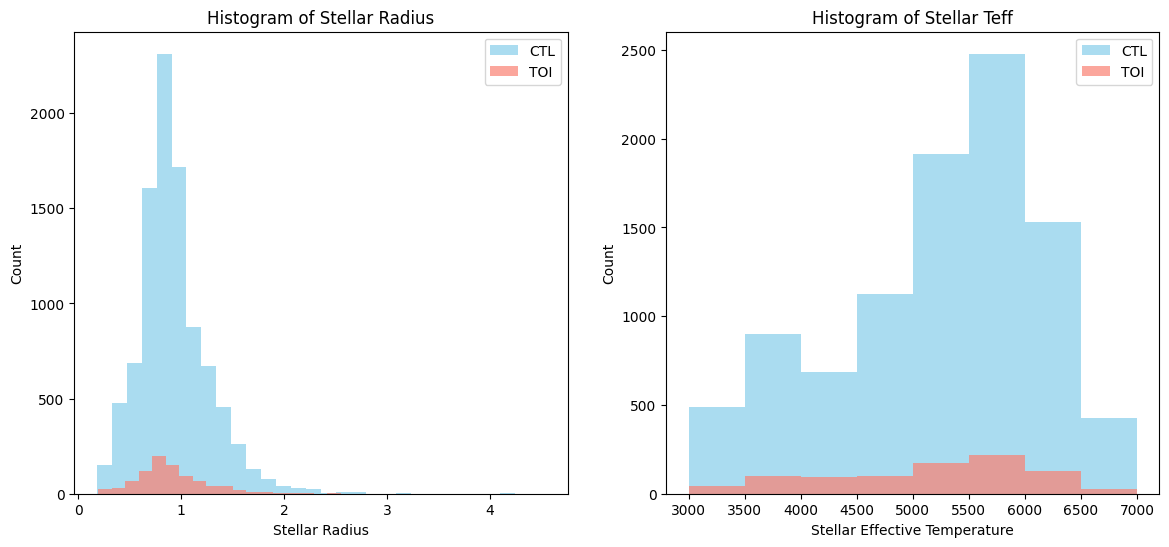

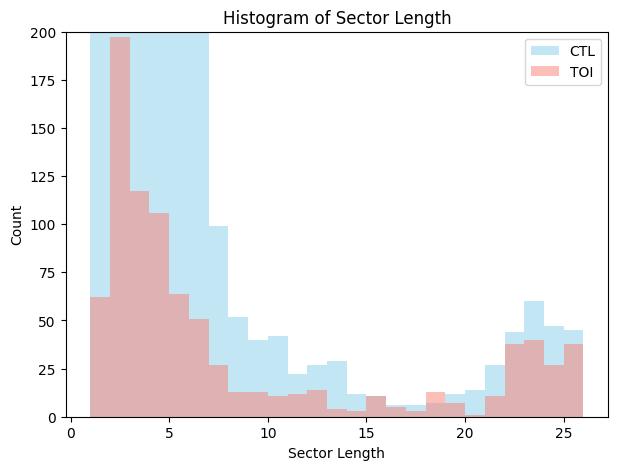

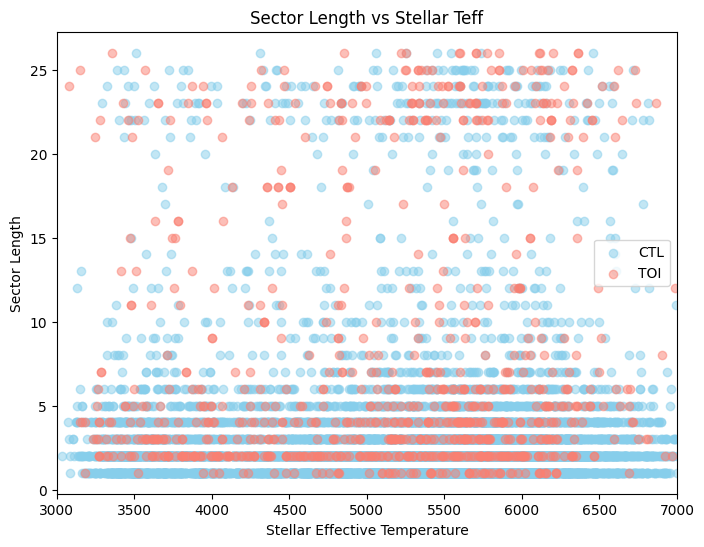

Teff bin (K) | CTL avg sector length | TOI avg sector length
3000-3500: 2.95 (CTL), 7.73 (TOI)
3500-4000: 3.14 (CTL), 6.73 (TOI)
4000-4500: 3.29 (CTL), 7.28 (TOI)
4500-5000: 3.06 (CTL), 8.35 (TOI)
5000-5500: 3.09 (CTL), 8.15 (TOI)
5500-6000: 3.19 (CTL), 7.29 (TOI)
6000-6500: 3.16 (CTL), 9.43 (TOI)
6500-7000: 3.42 (CTL), 10.54 (TOI)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


CTL_sectors = pd.read_csv("CTL_10x_with_sectors.csv")
#CTL_sectors = pd.read_csv('take_two_stellar_params_CTL.csv')
TOI_sectors = pd.read_csv("TOI_sector_results.csv")
plt.figure(figsize=(14, 6))

print("Length of CTL_sectors:", len(CTL_sectors))
print("Number of CTL stars with sector_length >= 1:", (CTL_sectors['sector_length'] >= 1).sum())
CTL_sectors = CTL_sectors[CTL_sectors['sector_length'] >= 1]

plt.subplot(1, 2, 1)
plt.hist(CTL_sectors['st_rad'], bins=30, alpha=0.7, label='CTL', color='skyblue')
plt.hist(TOI_sectors['st_rad'], bins=30, alpha=0.7, label='TOI', color='salmon')
plt.xlabel('Stellar Radius')
plt.ylabel('Count')
plt.title('Histogram of Stellar Radius')
plt.legend()

plt.subplot(1, 2, 2)
bins_teff = np.arange(3000, 7001, 500)
plt.hist(CTL_sectors['st_teff'], bins=bins_teff, alpha=0.7, label='CTL', color='skyblue')
plt.hist(TOI_sectors['st_teff'], bins=bins_teff, alpha=0.7, label='TOI', color='salmon')
plt.xlabel('Stellar Effective Temperature')
plt.ylabel('Count')
plt.title('Histogram of Stellar Teff')
plt.legend()

plt.figure(figsize=(7, 5))
n_ctl, bins_ctl_hist, patches_ctl = plt.hist(CTL_sectors['sector_length'], bins = 25, alpha=0.5, label='CTL', color='skyblue')
n_toi, bins_toi_hist, patches_toi = plt.hist(TOI_sectors['sector_length'], bins = 25, alpha=0.5, label='TOI', color='salmon')
plt.xlabel('Sector Length')
plt.ylabel('Count')
plt.title('Histogram of Sector Length')
plt.ylim(0, 200)
plt.legend()

# # Annotate counts on top of bars for CTL
# for count, x in zip(n_ctl, (bins_ctl_hist[:-1] + bins_ctl_hist[1:]) / 2):
#     if count > 0:
#         plt.text(x, count + 10, f"{int(count)}", ha='center', va='bottom', color='blue', fontsize=8, rotation=90)
# # Annotate counts on top of bars for TOI
# for count, x in zip(n_toi, (bins_toi_hist[:-1] + bins_toi_hist[1:]) / 2):
#     if count > 0:
#         plt.text(x, count + 30, f"{int(count)}", ha='center', va='bottom', color='red', fontsize=8, rotation=90)

plt.figure(figsize=(8, 6))
plt.scatter(CTL_sectors['st_teff'], CTL_sectors['sector_length'], alpha=0.5, label='CTL', color='skyblue')
plt.scatter(TOI_sectors['st_teff'], TOI_sectors['sector_length'], alpha=0.5, label='TOI', color='salmon')
plt.xlabel('Stellar Effective Temperature')
plt.ylabel('Sector Length')
plt.title('Sector Length vs Stellar Teff')
plt.xlim(3000,7000)
plt.legend()
plt.show()

teff_bins = bins_teff
ctl_avg = []
toi_avg = []
for i in range(len(teff_bins)-1):
    ctl_bin = CTL_sectors[(CTL_sectors['st_teff'] >= teff_bins[i]) & (CTL_sectors['st_teff'] < teff_bins[i+1])]
    toi_bin = TOI_sectors[(TOI_sectors['st_teff'] >= teff_bins[i]) & (TOI_sectors['st_teff'] < teff_bins[i+1])]
    ctl_avg.append(ctl_bin['sector_length'].mean())
    toi_avg.append(toi_bin['sector_length'].mean())

print("Teff bin (K) | CTL avg sector length | TOI avg sector length")
for i in range(len(teff_bins)-1):
    print(f"{teff_bins[i]}-{teff_bins[i+1]}: {ctl_avg[i]:.2f} (CTL), {toi_avg[i]:.2f} (TOI)")

In [2]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
for i in range(len(bins_teff)-1):
    toi_bin = TOIs[
        (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1]) &
        (TOIs['pl_orbper'] >= 0.7) & (TOIs['pl_orbper'] <= 25) &
        (TOIs['pl_rade'] >= 1.4) & (TOIs['pl_rade'] <= 5)
    ]
    plt.figure(figsize=(7,5))
    plt.scatter(toi_bin['pl_orbper'], toi_bin['pl_rade'], color='salmon', alpha=0.7)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Orbital Period (days, log scale)')
    plt.ylabel('Planet Radius (R$_\oplus$, log scale)')
    plt.title(f'TOI: Period vs Radius\nTeff {bins_teff[i]}-{bins_teff[i+1]} K')
    plt.grid(True, which='both', ls='--')
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'TOI_Mar2025_1pt5to4_R_with_extra_columns.csv'